In [10]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import matplotlib.pyplot as plt

例行导入各种模块

In [5]:
iris = load_iris()
X = iris.data
Y = iris.target
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,random_state=4)
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,Y_train)
y_pred=knn.predict(X_test)
print(knn.score(X_test,Y_test))

0.9736842105263158


从load_iris导入iris的各种数据，定义XY为基础属性和目标分类，划分训练集和测试集（随机数种子为4），创建k近邻分类器（默认n_neighbors=5）,输出结果R²

In [9]:
scores=cross_val_score(knn,X,Y,cv=5,scoring='accuracy')
print(scores.mean())

0.9733333333333334


增加导入交叉验证模块，利用5折交叉验证来再次输出得分，knn代表待评估的模型对象，XY为特征和标签数据，cv代表交叉验证折数，评价指标设置为准确度

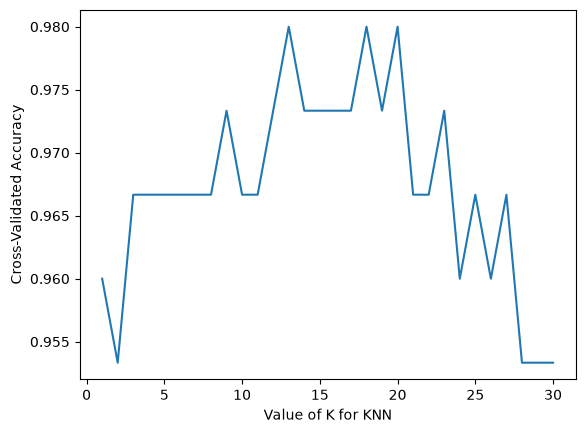

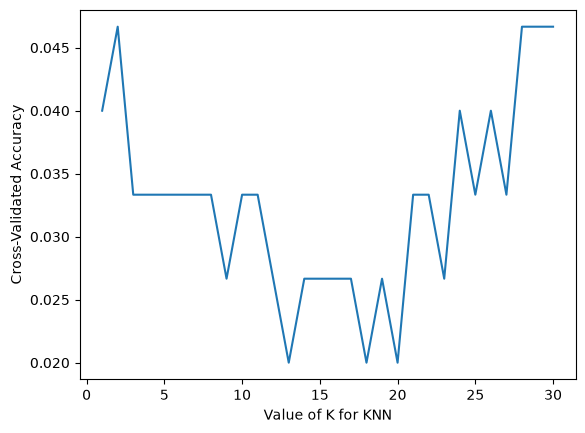

In [17]:
k_range=range(1,31)
k_scores=[]
k_loss=[]
for k in k_range:
    knn=KNeighborsClassifier(n_neighbors=k)
    scores=cross_val_score(knn,X,Y,cv=10,scoring='accuracy')  #for classification
    loss=-cross_val_score(knn,X,Y,cv=10,scoring='neg_mean_squared_error')  #for regression
    k_scores.append(scores.mean())
    k_loss.append(loss.mean()) 
plt.plot(k_range,k_scores)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()
plt.plot(k_range,k_loss)
plt.xlabel('Value of K for KNN')
plt.ylabel('Cross-Validated Accuracy')
plt.show()

新导入可视化模块，测试1，30都看一遍，哪个参数更好；10折交叉验证的得分平均值添加至记录分数的列表中,并将k和平均精度可视化;分类时是精度，回归时是均方误差MSE